# Ciência de Dados<br> Aula 1: Preparação e transformação dos dados

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

Um dos primeiros passos em Ciência de Dados é a preparação e transformação dos dados, de modo a prepará-los para etapas posteriores.

Nessa aula, vamos considerar dados com elementos duplicados ou faltantes e realizar a sua limpeza. Também vamos considerar métodos básicos de pré-processamento e transformação de dados.

Vamos ler um conjunto de dados com erros:

In [1]:
# gerador de números aleatórios
import random
from importlib.metadata import distribution

import seaborn
from pandas.core.common import random_state

random.seed(1)  # inicia a semente do gerador de números aleatórios. Importante para reprodução dos resultados
# Pandas are used for data manipulation
import pandas as pd  # biblioteca Pandas é usada para manipulação de dados
import matplotlib.pyplot as plt  # biblioteca para visualização dos dados

# CSV file
data = pd.read_csv('../../data/iris-with-errors.csv', header=0)
print("Número de linhas e colunas:", data.shape)
data.head(25)

Número de linhas e colunas: (25, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Primeiramente, vamos remover os "NaN" (not a number, que representam valores desconhecidos) do arquivo, apagando as linhas que contém esse problema. Notem que algumas linhas serão removidas, tais como a 5 e 9.

In [2]:
# remove as linhas com NaN
data = data.dropna()
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada


Vamos remover as linhas duplicadas. Para isso, inicialmente verificamos se há a ocorrência dessas linhas.

In [3]:
# Retorna True na posição em que há uma linha duplicada
data.duplicated()

0     False
1      True
2     False
3     False
4      True
6     False
7     False
8      True
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17     True
18    False
19    False
20    False
21    False
22    False
23    False
dtype: bool

Notem que indicamos nos dados originais, na última coluna, quais linhas estão duplicadas.

Para realizamos a remoção, usamos um método da biblioteca Pandas.

In [4]:
# Remove as linhas duplicadas
data = data.drop_duplicates()
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa


Compare essa tabela com a original (acima) e verifique se a remoção das linhas foi feita de forma correta. As linhas duplicadas são indicadas na última coluna.

Vamos remover as linhas que contenham "?" ou qualquer outro caracter que indique um erro ou entrada faltante.

Primeiramente, convertemos essas entradas para "NaN":

In [5]:
import numpy as np

# Substitui Nan por um character desejado
data = data.replace('?', np.nan)
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
2,NaN,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa


A seguir, fazemos a remoção, como anteriormente.

In [6]:
# Remove as linhas com Nan
data = data.dropna()
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


Desse forma, temos um conjunto de dados sem erros e entradas duplicadas. É fundamental realizar essas operações em qualquer conjunto de dados antes de aplicarmos os métodos de aprendizado de máquina e estatística.

Podemos também remover determinadas linhas e colunas dos dados. Para remover a segunda e quarta colunas:

In [7]:
print("Atributos atuais:", data.columns)
print("Colunas removidas:", data.columns[[1, 3]])
# Remove as linhas especificadas
data = data.drop(data.columns[[1, 3]], axis=1)
data.head(25)

Atributos atuais: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')
Colunas removidas: Index(['sepal_width', 'petal_width'], dtype='str')


,sepal_length,petal_length,species
0,5.1,1.4,duplicada
3,4.7,1.3,setosa
6,5,1.4,setosa
7,5.4,1.7,duplicada
10,5,1.5,setosa
11,4.4,1.4,duplicada
12,4.9,1.5,setosa
13,5.4,1.5,setosa
15,4.8,1.6,setosa
16,4.8,1.4,setosa


Para remover a primeira e terceira linhas:

In [8]:
data = data.drop(data.index[[0, 2]], axis=0)
print("Linhas Removidas:", data.index[[0, 2]])
data.head(25)

Linhas Removidas: Index([3, 10], dtype='int64')


,sepal_length,petal_length,species
3,4.7,1.3,setosa
7,5.4,1.7,duplicada
10,5,1.5,setosa
11,4.4,1.4,duplicada
12,4.9,1.5,setosa
13,5.4,1.5,setosa
15,4.8,1.6,setosa
16,4.8,1.4,setosa
18,4.3,1.1,setosa
19,5.8,1.2,setosa


## Substituição de valores ausentes

Em muitas siutações, a matriz de atributos pode conter valores ausentes. Nesse caso, podemos usar diferentes métodos para substituir tais valores, como preenche-los com valores médios ou medianas.

Vamos ler os dados novamente:

In [9]:
data = pd.read_csv('../../data/iris-with-errors.csv', header=0)
print(data.shape)
data.head(25)

(25, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Vamos substituir os valores com 'NaN' e '?' pelos valores médios dos atributos. Primeiramente, mudamos as entradas '?' para 'NaN', como foi feito anteriormente.

In [10]:
import numpy as np

data = data.replace('?', np.nan)
data.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,NaN,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


A seguir, inserimos a média de cada atributo nas entradas com valores 'NaN'.

In [11]:
# convertemos para o formato Numpy e ignoramos a última coluna (classe)
X = np.array(data[data.columns[0:data.shape[1] - 1]], dtype=float)
# calculamos a média de cada atributo e armazenamos em um vetor
# Usamos a função nanmean que calcula a média ignorando os Nan
averages = np.nanmean(X, axis=0)  # veja https://docs.scipy.org/doc/numpy/reference/generated/numpy.nanmean.html
for i in np.arange(0, X.shape[0]):
    for j in np.arange(0, X.shape[1]):
        if np.isnan(X[i, j]) == True:  # verificar se é uma entrada com Nan
            X[i, j] = averages[j]  # insere a média
print(X)

[[5.1        3.5        1.4        0.2       ]
 [5.1        3.5        1.4        0.2       ]
 [5.02272727 3.         1.4        0.2       ]
 [4.7        3.2        1.3        0.2       ]
 [5.1        3.5        1.4        0.2       ]
 [5.02272727 3.1        1.5        0.2       ]
 [5.         3.6        1.4        0.2       ]
 [5.4        3.9        1.7        0.4       ]
 [5.4        3.9        1.7        0.4       ]
 [4.6        3.4        1.4        0.22608696]
 [5.         3.4        1.5        0.2       ]
 [4.4        2.9        1.4        0.2       ]
 [4.9        3.1        1.5        0.1       ]
 [5.4        3.7        1.5        0.2       ]
 [4.4        2.9        1.4        0.2       ]
 [4.8        3.4        1.6        0.2       ]
 [4.8        3.         1.4        0.1       ]
 [4.4        2.9        1.4        0.2       ]
 [4.3        3.         1.1        0.1       ]
 [5.8        4.         1.2        0.2       ]
 [5.7        4.4        1.5        0.4       ]
 [5.4        

Assim como inserimos a média, poderíamos inserir a mediana ou qualquer outro valor.

## Normalização e padronização

Vamos ler os dados:

In [12]:
import pandas as pd
from sklearn.datasets import load_iris

# CSV file
data = load_iris(as_frame=True).frame
print(data.shape)
data.head(25)

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Para normalizar os dados no intervalo [0,1]:

In [13]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# considera somente os atributos, ignorando a última coluna, que contem a classe
X = np.array(data[data.columns[0:data.shape[1] - 1]])
for i in range(X.shape[1]):
    print(f"Menor Valor da coluna {i}:", min(X[:, i]))
    print(f"Maior valor da coluna {i}:", max(X[:, i]))
# prepara a função para transformar os dados
scaler = MinMaxScaler(feature_range=(0, 1))
# Realiza a normalização e coloca em um novo vetor
X_norm = scaler.fit_transform(X)
X_norm

Menor Valor da coluna 0: 4.3
Maior valor da coluna 0: 7.9
Menor Valor da coluna 1: 2.0
Maior valor da coluna 1: 4.4
Menor Valor da coluna 2: 1.0
Maior valor da coluna 2: 6.9
Menor Valor da coluna 3: 0.1
Maior valor da coluna 3: 2.5


array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

Ou seja, o máximo e mínimo do novo conjunto de dados:

In [14]:
print('Mínimo dos atributos:', np.amin(X_norm, axis=0))
print('Máximo dos atributos:', np.amax(X_norm, axis=0))

Mínimo dos atributos: [0. 0. 0. 0.]
Máximo dos atributos: [1. 1. 1. 1.]


Para realizarmos a padronização dos dados, de forma que os atributos apresentem média igual a zero e variância igual a 1, o procedimento é parecido.

In [15]:
from sklearn.preprocessing import StandardScaler

X = np.array(data[data.columns[0:data.shape[1] - 1]])
# prepara a função para transformar os dados
scaler = StandardScaler().fit(X)
# realiza a padronização (média=0, variância = 1)
rescaledX = scaler.transform(X)
rescaledX

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

Vamos verificar se cada coluna apresenta média igual a zero e desvio padrão igual a um.

In [16]:
for i in np.arange(0, rescaledX.shape[1]):
    print(f'Média da coluna {i} é igual a:', np.mean(rescaledX[:, i]))
    print(f'Desvio padrão da coluna {i} é igual a:', np.std(rescaledX[:, i]), '\n')

Média da coluna 0 é igual a: -1.4684549872375404e-15
Desvio padrão da coluna 0 é igual a: 1.0 

Média da coluna 1 é igual a: -1.8237263551175904e-15
Desvio padrão da coluna 1 é igual a: 1.0000000000000004 

Média da coluna 2 é igual a: -1.6105635343895603e-15
Desvio padrão da coluna 2 é igual a: 0.9999999999999999 

Média da coluna 3 é igual a: -9.473903143468002e-16
Desvio padrão da coluna 3 é igual a: 1.0 



## Binarização dos dados

A binarização dos dados resulta em valores zero ou um, de acordo com um dado limiar. Ou seja, se o valor em X for maior do que o limiar, o valor resultante será 1, caso contrário será zero.
$$
X_{novo}(i, j) =
\begin{cases} 1, & \mbox{se } X(i, j) \geq T \\ 0, & \mbox{se } X(i, j) < T \end{cases}
$$

In [17]:
from sklearn.preprocessing import Binarizer
from sklearn.preprocessing import MinMaxScaler

# considera apenas os atributos, ignorando a última coluna das classes
X = np.array(data[data.columns[0:data.shape[1] - 1]], dtype=float)
T = 0.2  # valor do limiar
print('Limiar:', T)
print('---------------------')

# prepara a normalização dos dados
scaler = MinMaxScaler(feature_range=(0, 1))
# realiza a normalização
X_pad = scaler.fit_transform(X)
# faz a binarização considerando o limiar (threshold)
binarizer = Binarizer(threshold=T).fit(X_pad)
binaryX = binarizer.transform(X_pad)
for i in np.arange(0, X_pad.shape[0]):
    print("Antes:", X_pad[i,])
    print('Depois:', binaryX[i,])
    print('---------------------')

Limiar: 0.2
---------------------
Antes: [0.22222222 0.625      0.06779661 0.04166667]
Depois: [1. 1. 0. 0.]
---------------------
Antes: [0.16666667 0.41666667 0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.11111111 0.5        0.05084746 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.08333333 0.45833333 0.08474576 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.19444444 0.66666667 0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.30555556 0.79166667 0.11864407 0.125     ]
Depois: [1. 1. 0. 0.]
---------------------
Antes: [0.08333333 0.58333333 0.06779661 0.08333333]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.19444444 0.58333333 0.08474576 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.02777778 0.375      0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.16666667 0.45833333 0.08474576 0.        ]
Depois: [0. 1. 0. 0.]
------------------

## Conversão de variáveis nominais em inteiros

Quando temos dados nominais e ordinais, podemos convertê-los para variáveis numéricas. Vamos fazer isso com as classes dos dados, mudando os valores nominais para inteiros.

In [18]:
# leitura dos dados
data = pd.read_csv('../../data/iris-categorical-classes.csv', header=0)
print('Número de linhas e colunas:', data.shape)
# mostramos a última coluna
print('Coluna com as classes:\n')
data[data.columns[-1]]

Número de linhas e colunas: (150, 5)
Coluna com as classes:



0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

In [19]:
# armazena o nome das classes
classes = np.unique(data[data.columns[-1]])
number = 0  # valor que será usado para representar as classes
for i in classes:
    data = data.replace(i, number)  # substitui cada valor da classe por number
    number = number + 1
print('Novos dados:')
data[data.columns[-1]]

Novos dados:


0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: object

Esse mesmo procedimento pode ser usado em qualquer uma das colunas da matriz de atributos.

## One-hot encoding

Quando temos variáveis nominais e precisamos transformá-las para numéricas, uma maneira simples é usar o método one-hot encoding. 

In [20]:
import pandas as pd

# cria um dataframe do Pandas
df = pd.DataFrame({
    'A': ['a', 'b', 'a', 'c', 'a', 'b'],
})
df.head()

,A
0,a
1,b
2,a
3,c
4,a


Usando one-hot enconding, obtemos:

In [21]:
df = pd.get_dummies(df)
df.head()

,A_a,A_b,A_c
0,True,False,False
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False


Note que foi usado um código binário para cada valor nominal.

## Dados correlacionados

Vamos identificar as colunas em que a correlação entre elas é maior do que $|p|$.

In [22]:
data = pd.read_csv('../../data/BostonHousing.csv', header=0)
data.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


A matriz de correlação entre as variáveis:

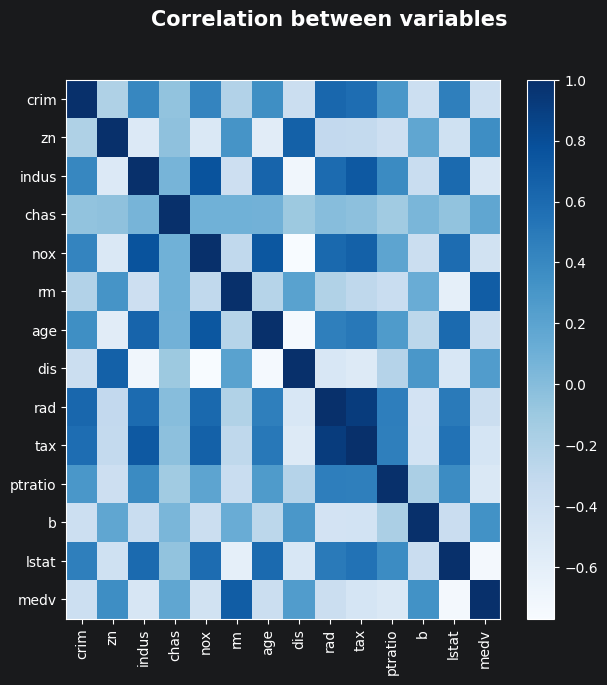

In [23]:
# obtém a matriz de correlação dos dados
corr = data.corr()
# Mostra a matriz
plt.figure(figsize=(7, 7))
# imshow é usado para mostrar imagens
plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
# mostra a barra lateral de cores
plt.colorbar()
# inclui o nome das variáveis
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns)
plt.suptitle('Correlation between variables', fontsize=15, fontweight='bold')
plt.grid(False)
plt.show()

Os dados estão armazenados na matriz:

In [24]:
corr

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Assim, para identificarmos as variáveis correlacionadas, usamos um laço for:

In [25]:
p = 0.75  # correlação mínima
var = []
for i in corr.columns:
    for j in corr.columns:
        if i != j and np.abs(corr[i][j]) > p:  # se maior do que |p|
            var.append([i, j])
print('Variáveis mais correlacionadas:\n', var)

Variáveis mais correlacionadas:
 [['indus', 'nox'], ['nox', 'indus'], ['nox', 'dis'], ['dis', 'nox'], ['rad', 'tax'], ['tax', 'rad']]


Com isso, podemos remover as variáveis mais correlacionadas de modo a reduzir a redundância nos dados.

## Dados desbalanceados

Muitas vezes, o número de observações difere em cada classe, de modo que os dados são desbalanceados. Podemos verificar o número de elementos em cada classe criando um histograma.

In [26]:
data = pd.read_csv('../../data/Vehicle.csv', header=0)
data.head(10)

,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


In [27]:
classes = data[data.columns[-1]]
classes

0       van
1       van
2      saab
3       van
4       bus
       ... 
841    saab
842     van
843    saab
844    saab
845     van
Name: Class, Length: 846, dtype: str

O histograma do número de elementos em cada classe:

In [28]:
# armazena os nomes das classes
cl = np.unique(classes)
# armazena o número de elementos em cada classe
ncl = np.zeros(len(cl))
for i in np.arange(0, len(cl)):
    a = classes == cl[i]
    ncl[i] = len(classes[a])
print(ncl)

[218. 212. 217. 199.]


Em um gráfico de barras:

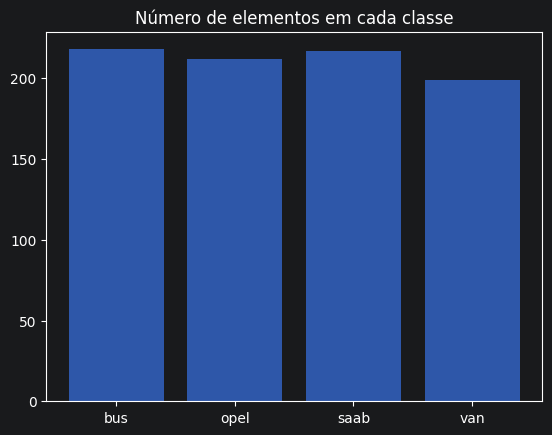

In [29]:
# número de classes
numbers = np.arange(0, len(cl))
plt.bar(numbers, ncl, alpha=.75)
# mostra o nome das classes ao invés dos números
plt.xticks(numbers, cl)
plt.title('Número de elementos em cada classe')
plt.show(True)

Podemos redistribuir os dados de modo que cada classes contenha o mesmo número de elementos.

Vamos balancear os dados de forma que cada classe contenha $N$ elementos. Escolhermos $N$ elementos de forma aleatória, sem reposição, de cada classe.

In [30]:
N = 3
# classes
cl = np.unique(classes)
X = np.array(data)
Xnew = []
cls = np.array(data[data.columns[-1]])
rnd_generator = np.random.default_rng(seed=42)
for i in np.arange(0, len(cl)):
    a = np.argwhere(cls == cl[i])
    # seleciona os índices nos dados de forma aleatória
    inds = rnd_generator.choice(a[:, 0], N, replace=False)
    Xnew.append(X[inds, :])
Xnew = np.array(Xnew)
print('Dados obtidos a partir da amostragem')
print(Xnew)

Dados obtidos a partir da amostragem
[[[107 55 103 167 49 7 252 27 28 172 269 904 239 83 5 30 179 186 'bus']
  [104 52 94 208 66 5 208 31 24 161 227 666 218 76 11 4 193 191 'bus']
  [84 43 76 180 75 7 155 43 19 143 180 359 173 77 5 12 185 190 'bus']]

 [[80 37 57 116 55 6 125 54 18 125 142 229 132 81 8 5 178 184 'opel']
  [98 55 108 168 53 11 224 30 25 178 231 737 217 73 8 30 187 198 'opel']
  [95 42 96 197 65 9 178 37 21 141 199 474 149 67 1 29 193 200 'opel']]

 [[97 45 76 175 60 9 157 42 20 149 180 370 169 63 16 12 198 206 'saab']
  [108 49 109 204 61 11 212 31 24 159 229 665 215 71 16 11 190 199
   'saab']
  [89 38 77 161 62 7 149 45 19 129 174 327 153 71 6 21 188 193 'saab']]

 [[87 42 64 150 64 10 133 50 18 141 157 265 159 67 7 0 193 201 'van']
  [91 39 77 153 59 8 139 48 18 139 159 289 123 62 8 17 201 209 'van']
  [89 41 84 141 58 9 149 45 19 145 172 330 162 72 4 18 188 200 'van']]]


## Outliers - Box plot

Em muitos casos, temos a presença de outliers nos dados. Uma maneira simples de identificar outliers é criando um boxplot.

Lembrem-se, um boxplot:

<img src="https://cdn-images-1.medium.com/max/1600/1*2c21SkzJMf3frPXPAR_gZA.png" style="height:300px"> 

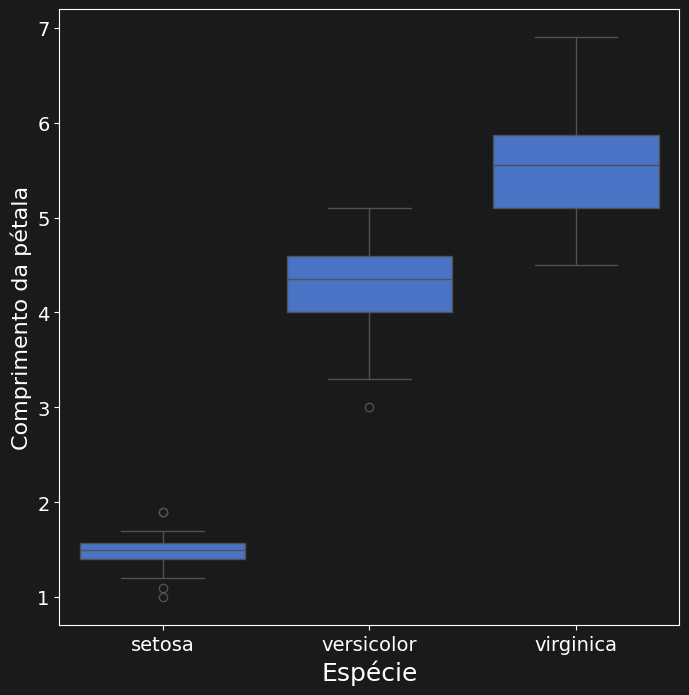

In [31]:
# biblioteca para mostrar os gráficos
import seaborn as sns

data = pd.read_csv('../../data/iris-categorical-classes.csv', header=0)
plt.figure(figsize=(8, 8))
# mostra o boxplot
sns.boxplot(x="species", y="petal_length", data=data)
plt.xlabel('Espécie', fontsize=18)
plt.ylabel('Comprimento da pétala', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show(True)

Podemos ainda usar a distância interquantil (Q3 - Q1) para encontrar os outliers de uma forma simples. Vamos considerar um exemplo.

In [32]:
np.random.seed(101)
# geramos os dados de forma aleatória e colocamos em um dataframe
random = np.random
data = pd.DataFrame({'a': random.randint(1, 200, 20),
                     'b': random.randint(1, 200, 20),
                     'c': random.randint(1, 200, 20)})

# geramos os outliers, aumentando em 10 vezes o valor dos atributos
data[data > 150] = data[data > 150] * 10
# mostramos os dados
data

,a,b,c
0,96,112,100
1,12,137,29
2,82,116,64
3,71,1580,8
4,64,116,139
5,88,60,1810
6,76,1630,1850
7,138,45,104
8,41,73,39
9,133,20,74


Visualizando os dados:

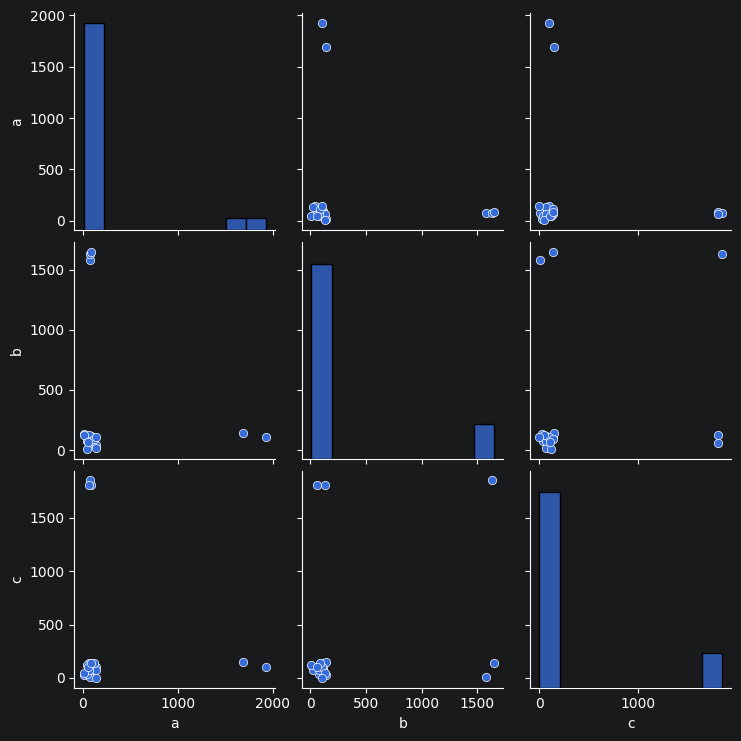

In [33]:
import seaborn as sns

sns.pairplot(data)
plt.show()

Para encontrarmos os outliers:

In [34]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))

,a,b,c
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
5,False,False,True
6,False,True,True
7,False,False,False
8,False,False,False
9,False,False,False


Podemos dizer que uma observação é um outlier se ao menos uma das variáveis está fora dos limites máximos do boxplot. Ou seja, se o valor é menor do que (Q1 - 1.5 * IQR) ou maior do que (Q3 + 1.5 * IQR).
Outliers são indicados como True abaixo.

In [35]:
((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)  #~is used to invert the answer

0     False
1     False
2     False
3      True
4     False
5      True
6      True
7     False
8     False
9     False
10     True
11     True
12    False
13     True
14    False
15    False
16    False
17    False
18    False
19     True
dtype: bool

A partir dessa informação, podemos fazer a retirada dos outliers no dados originais.

In [36]:
v = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
#v = np.invert(v)
data = data.drop(data.index[list(v)], axis=0)
data.head(25)

,a,b,c
0,96,112,100
1,12,137,29
2,82,116,64
4,64,116,139
7,138,45,104
8,41,73,39
9,133,20,74
12,61,77,72
14,111,88,144
15,6,129,45


## Exercícios de fixação

1 - Leia os dados com erro novamente, faça a limpeza e remova as duas últimas colunas.

2 - Leia os dados com erro novamente e insira a mediana de cada atributo onde for encontrada NaN.

3 - Considere os dados da Iris e mostre a distribuição de probabilidades de cada uma das variáveis após a normalização e padronização.

4 - Reamostre os dados da Iris e selecione 10 elementos em cada classe.

5 - Monte um boxplot para cada variável dos dados da Iris.

6 - Encontre os outliers nos dados das bases Iris e BostonHouse.

In [89]:
# 1
data = pd.read_csv('../../data/iris-with-errors.csv', header=0)

data = data.drop(['petal_width', 'species'], axis=1)

data = data.drop_duplicates()

data = data.replace('?', np.nan)

data = data.astype({'sepal_length': 'float', 'sepal_width': 'float'})

median_array = data.mean(numeric_only=True, skipna=True)

for col in data.columns:
    data[col] = data[col].fillna(median_array[col])

print(median_array)
data

sepal_length    5.062500
sepal_width     3.461111
petal_length    1.436842
dtype: float64


,sepal_length,sepal_width,petal_length
0,5.1000,3.500000,1.4
2,5.0625,3.000000,1.4
3,4.7000,3.200000,1.3
5,5.0625,3.100000,1.5
6,5.0000,3.600000,1.4
7,5.4000,3.900000,1.7
9,4.6000,3.400000,1.4
10,5.0000,3.400000,1.5
11,4.4000,2.900000,1.4
12,4.9000,3.100000,1.5


In [90]:
# 2
data = pd.read_csv('../../data/iris-with-errors.csv', header=0)

data = data.drop(['petal_width', 'species'], axis=1)

data = data.drop_duplicates()

data = data.replace('?', np.nan)

data = data.astype({'sepal_length': 'float', 'sepal_width': 'float'})

median_array = data.median(numeric_only=True, skipna=True)

for col in data.columns:
    data[col] = data[col].fillna(median_array[col])

print(median_array)
data

sepal_length    5.0
sepal_width     3.4
petal_length    1.4
dtype: float64


,sepal_length,sepal_width,petal_length
0,5.1,3.5,1.4
2,5.0,3.0,1.4
3,4.7,3.2,1.3
5,5.0,3.1,1.5
6,5.0,3.6,1.4
7,5.4,3.9,1.7
9,4.6,3.4,1.4
10,5.0,3.4,1.5
11,4.4,2.9,1.4
12,4.9,3.1,1.5


Média da coluna 0 é igual a: -1.4684549872375404e-15
Desvio padrão da coluna 0 é igual a: 1.0 

Média da coluna 1 é igual a: -1.8237263551175904e-15
Desvio padrão da coluna 1 é igual a: 1.0000000000000004 

Média da coluna 2 é igual a: -1.6105635343895603e-15
Desvio padrão da coluna 2 é igual a: 0.9999999999999999 

Média da coluna 3 é igual a: -9.473903143468002e-16
Desvio padrão da coluna 3 é igual a: 1.0 



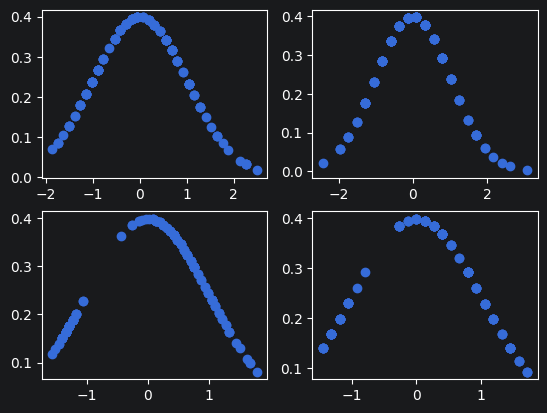

In [118]:
# 3
import scipy.stats as stats

data = load_iris(as_frame=True).data
X = data.to_numpy()

scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)

for i in range(rescaledX.shape[1]):
    print(f'Média da coluna {i} é igual a:', np.mean(rescaledX[:, i]))
    print(f'Desvio padrão da coluna {i} é igual a:', np.std(rescaledX[:, i]), '\n')

distributions = []
for i in range(rescaledX.shape[1]):
    distributions.append(stats.norm.pdf(rescaledX[:, i], 0, 1))

fig, axes = plt.subplots(2, 2)
axes[0][0].scatter(rescaledX[:, 0], distributions[0])
axes[0][1].scatter(rescaledX[:, 1], distributions[1])
axes[1][0].scatter(rescaledX[:, 2], distributions[2])
axes[1][1].scatter(rescaledX[:, 3], distributions[3])
plt.show()

In [123]:
# 4
data = load_iris(as_frame=True).frame

ten_random_by_class = data.groupby('target').sample(n=10, random_state=42)
ten_random_by_class

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
13,4.3,3.0,1.1,0.1,0
39,5.1,3.4,1.5,0.2,0
30,4.8,3.1,1.6,0.2,0
45,4.8,3.0,1.4,0.3,0
17,5.1,3.5,1.4,0.3,0
48,5.3,3.7,1.5,0.2,0
26,5.0,3.4,1.6,0.4,0
25,5.0,3.0,1.6,0.2,0
32,5.2,4.1,1.5,0.1,0
19,5.1,3.8,1.5,0.3,0


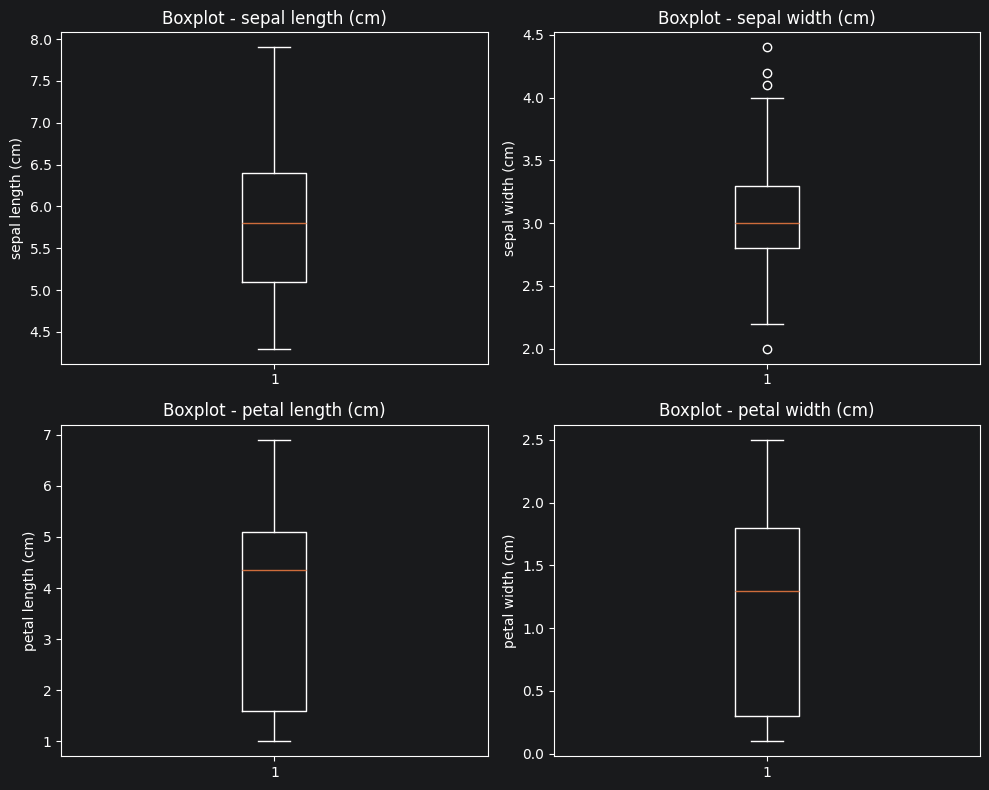

In [145]:
# 5
data = load_iris(as_frame=True).data

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(data.columns):  # Exclude target column
    axes[i].boxplot(data[col])
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [148]:
# 6

# ===== IRIS =====
data_iris = load_iris(as_frame=True).frame

def find_outliers_iqr(data, columns=None):
    if columns is None:
        columns = data.select_dtypes(include=[np.number]).columns

    outliers = pd.DataFrame()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask = (data[col] < lower) | (data[col] > upper)
        print(f"{col}: {mask.sum()} outliers (bounds: {lower:.2f} - {upper:.2f})")

    return mask

print("=== IRIS OUTLIERS ===")
find_outliers_iqr(data_iris, data_iris.columns[:-1])

# ===== BOSTON HOUSING =====

data = pd.read_csv('../../data/BostonHousing.csv')

print("\n=== BOSTON HOUSING OUTLIERS ===")
find_outliers_iqr(data)

=== IRIS OUTLIERS ===
sepal length (cm): 0 outliers (bounds: 3.15 - 8.35)
sepal width (cm): 4 outliers (bounds: 2.05 - 4.05)
petal length (cm): 0 outliers (bounds: -3.65 - 10.35)
petal width (cm): 0 outliers (bounds: -1.95 - 4.05)

=== BOSTON HOUSING OUTLIERS ===
crim: 66 outliers (bounds: -5.31 - 9.07)
zn: 68 outliers (bounds: -18.75 - 31.25)
indus: 0 outliers (bounds: -14.18 - 37.47)
chas: 35 outliers (bounds: 0.00 - 0.00)
nox: 0 outliers (bounds: 0.19 - 0.89)
rm: 30 outliers (bounds: 4.78 - 7.73)
age: 0 outliers (bounds: -28.55 - 167.65)
dis: 5 outliers (bounds: -2.53 - 9.82)
rad: 0 outliers (bounds: -26.00 - 54.00)
tax: 0 outliers (bounds: -301.50 - 1246.50)
ptratio: 15 outliers (bounds: 13.20 - 24.40)
b: 77 outliers (bounds: 344.11 - 427.50)
lstat: 7 outliers (bounds: -8.06 - 31.96)
medv: 40 outliers (bounds: 5.06 - 36.96)


0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Name: medv, Length: 506, dtype: bool